# 과제 3 - 클러스터링
### customer_segments.csv 파일의 데이터를 군집화 수행

#### customer_dataspec(데이터명세서) 참고
- 군집에 쓸 특징(입력 변수)
- Recency_Days : 마지막 구매 후 경과일(작을수록 최근)
- Frequency_90D : 최근 90일 구매 횟수
- Monetary_90D : 최근 90일 구매금액(원)
- Avg_Basket : 평균 객단가(원)
- Discount_Ratio : 할인 구매 비율(0~1)
- Return_Ratio : 반품 비율(0~1)
- Web_Visits_30D : 최근 30일 방문횟수
- App_Sessions_30D : 앱 세션 수
- Review_Score : 리뷰 평균(1~5)
- Region : 지역(범주형, 군집 전에 인코딩/제외 선택)

In [ ]:
# 커널 확인
print("hello")


hello


In [2]:
# /data/customer_segments.csv csv 불러오기
import pandas as pd
customer_segments = pd.read_csv("./data/customer_segments.csv")
customer_segments.head()


,Customer_ID,Recency_Days,Frequency_90D,Monetary_90D,Avg_Basket,Discount_Ratio,Return_Ratio,Web_Visits_30D,App_Sessions_30D,Review_Score,Region
0,30001,24,9,505714,45856,0.47,0.05,16,10,4.7,Seoul
1,30002,42,2,73314,41320,0.22,0.01,10,4,4.0,Seoul
2,30003,39,10,215402,23642,0.20,0.14,11,14,3.3,Seoul
3,30004,21,4,343927,65800,0.15,0.07,9,3,4.0,Seoul
4,30005,2,19,1633920,70789,0.17,0.05,18,46,4.8,Seoul


In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [18]:
# ID, Region drop
features = [col for col in customer_segments.columns if col not in ['Customer_ID', 'Region']]
X = customer_segments[features]
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Recency_Days      8000 non-null   int64  
 1   Frequency_90D     8000 non-null   int64  
 2   Monetary_90D      8000 non-null   int64  
 3   Avg_Basket        8000 non-null   int64  
 4   Discount_Ratio    8000 non-null   float64
 5   Return_Ratio      8000 non-null   float64
 6   Web_Visits_30D    8000 non-null   int64  
 7   App_Sessions_30D  8000 non-null   int64  
 8   Review_Score      8000 non-null   float64
 9   Cluster           8000 non-null   int64  
dtypes: float64(3), int64(7)
memory usage: 625.1 KB


In [5]:
# data scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [11]:
# eps와 min_samples 파라미터 설정
dbscan = DBSCAN(eps=3, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

customer_segments['Cluster'] = clusters

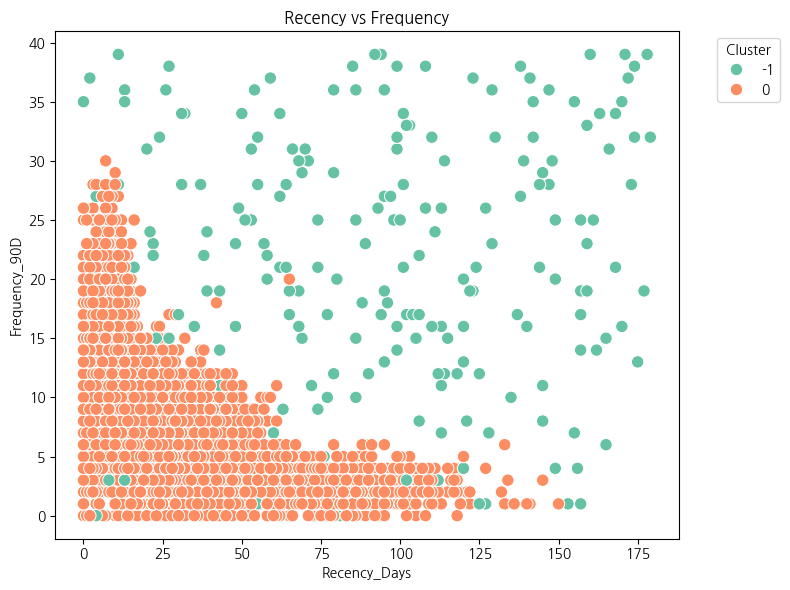

In [ ]:
# 시각화: Recency vs Frequency
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.scatterplot(data=customer_segments, x='Recency_Days', y='Frequency_90D', 
               hue='Cluster', palette='Set2', s=80)
plt.title('Recency vs Frequency')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

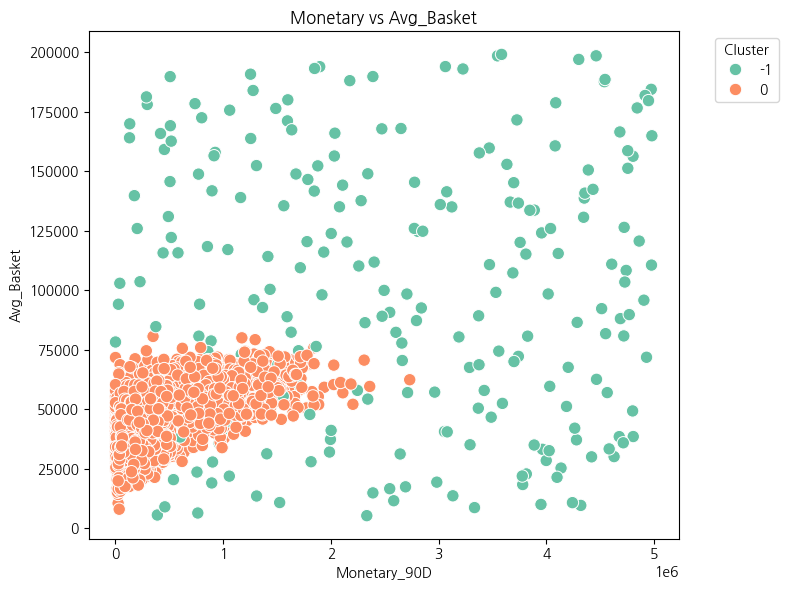

In [16]:
# Monetary vs Avg_Basket
plt.figure(figsize=(8, 6))
sns.scatterplot(data=customer_segments, x='Monetary_90D', y='Avg_Basket', 
               hue='Cluster', palette='Set2', s=80)
plt.title('Monetary vs Avg_Basket')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()